# Long-Term Statistics and Visualization of Extreme Climate Events (AHT/HR/MHW)


Creation Date: 12-Dec-2025                                                                                                          
Please contact Yun-Young Lee (dolkong400@gmail.com), Team ART(AI-based prediction Research and Technology)/APCC(APEC Climate Center)

This code performs the following tasks:
 - Calculates the long-term mean and trend of three event statistics 
   (Frequency, Total Days, Mean Intensity) for:
     • Anomalous High Temperature (AHT)
     • Heavy Rainfall (HR)
     • Marine Heatwaves (MHW)
   across the East Asia domain.
 - Generates 2D maps displaying the long-term mean and the trend (per decade).



## 0. Imports

In [9]:
import os
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import BoundaryNorm
import cartopy.crs as ccrs
from scipy.stats import linregress
# from tqdm.notebook import tqdm
from tqdm import tqdm
from IPython.display import display, Image

%matplotlib inline


## 1. Paths and target extreme event configuration

In [ ]:
dir0 = 'YOUR WORKING DIRECTORY/'
dir_in = dir0 + 'DATA/0.ExtremeEvents_ERA5_OISST/'
dir_out1 = dir0 + 'OUTPUTS/'
dir_out2 = dir0 + 'IMAGES/'

rg = 'EA1.5'

hd = 'mhw'  # 'aht' or 'hr' or 'mhw'
mtr = 'event90_D5G2'
    # 'aht': mtr = 'event90_D5G2' 'event90_D3G5' 'event95_D5G2' 'event95_D3G5'
    # 'hr':  mtr = 'event90_D1G3' 'event90_D3G3' 'event95_D1G3' 'event95_D3G3'
    # 'mhw': mtr = 'event90_D5G2' 'event90_D3G5' 'event95_D5G2' 'event95_D3G5'
rean = 'oisst'  # 'era5' or 'oisst'
syr, eyr = 1982, 2024
nyr = eyr - syr + 1
prd = f'{syr}-{eyr}'

print(f"hd={hd}, mtr={mtr}, rean={rean}, period={prd} ({nyr} yr)")


hd=mhw, mtr=event90_D5G2, rean=oisst, period=1982-2024 (43 yr)


## 2. Helper functions

In [11]:
def panel(irow, icol, lat, lon, x, cmap, levs, mn, mx, ttl, fs, fw, ha, opt_cbar, clb, fig, gs):
    ax = fig.add_subplot(gs[irow, icol], projection=ccrs.PlateCarree())
    ax.coastlines()

    intlon, intlat = lon[1] - lon[0], lat[1] - lat[0]
    lon_edges = np.linspace(lon[0], lon[-1] + intlon, len(lon) + 1) - intlon / 2.
    lat_edges = np.linspace(lat[0], lat[-1] + intlat, len(lat) + 1) - intlat / 2.

    cmap_obj = plt.get_cmap(cmap)
    norm = BoundaryNorm(levs, ncolors=cmap_obj.N, clip=True)

    im = ax.pcolormesh(lon_edges, lat_edges, x, cmap=cmap_obj, norm=norm,
                        shading='auto', transform=ccrs.PlateCarree(), zorder=0)
    ax.set_extent([lon_edges[0], lon_edges[-1], lat_edges[0], lat_edges[-1]], crs=ccrs.PlateCarree())
    ax.set_title(ttl, fontsize=fs + 5, fontweight='heavy')

    if opt_cbar == 1:
        cax = fig.add_subplot(gs[irow, icol + 1])
        fig.colorbar(im, cax=cax, orientation='vertical')
    elif opt_cbar == 2:
        cax = fig.add_subplot(gs[irow + 1, icol])
        cbar = fig.colorbar(im, cax=cax, orientation='horizontal')
        cbar.set_label(f'[{clb}]', fontsize=fs - 5, fontweight=fw, loc='right', labelpad=1)
    elif opt_cbar == 3:
        fig.colorbar(im, ax=ax, orientation='vertical')

    return im


def aggregate_by_year(dates, values, how='mean'):
    s = pd.Series(values, index=[d.year for d in dates])
    grouped = s.groupby(level=0)
    return getattr(grouped, how)().to_dict()


def regress_trend(yearly_dict):
    if len(yearly_dict) < 2:
        return np.nan
    years = np.array(list(yearly_dict.keys()), dtype=float)
    values = np.array(list(yearly_dict.values()), dtype=float)
    slope, *_ = linregress(years, values)
    return slope


def compute_pixel_stats(mtr_data, loc_key, syr):
    n_events_dict = mtr_data['n_events']
    if loc_key not in n_events_dict:
        return None

    peak_dates = list(mtr_data['date_peak'][loc_key])
    if not peak_dates:
        return None

    years_array = np.array([d.year for d in peak_dates])
    valid_mask = years_array >= syr
    if not valid_mask.any():
        return None
    idx = int(np.argmax(valid_mask))

    durations = np.array(mtr_data['duration'][loc_key])[idx:]
    intensities = np.array(mtr_data['intensity_mean'][loc_key])[idx:]
    dates = peak_dates[idx:]

    freq_yearly = aggregate_by_year(dates, durations, 'count')
    days_yearly = aggregate_by_year(dates, durations, 'sum')
    intensity_yearly = aggregate_by_year(dates, intensities, 'mean')

    return {
        'freq': len(dates),
        'total_days': float(np.sum(durations)),
        'mean_intensity': float(np.mean(intensities)),
        'freq_trend': regress_trend(freq_yearly),
        'days_trend': regress_trend(days_yearly),
        'intensity_trend': regress_trend(intensity_yearly),
    }


## 3. Load event pickle file

In [12]:
fn = dir_in + f'{hd.upper()}.Event.{rean.upper()}.{prd}.{rg}.pkl'
print(f"Loading: {fn}")

with open(fn, 'rb') as f:
    data = pickle.load(f)

lat, lon = data['lat'], data['lon']
ny, nx = len(lat), len(lon)
print(f"Grid size: ({ny}, {nx})")
print("Available detection criteria:", [k for k in data.keys() if k.startswith('event')])


Loading: /home/yyalee/ART_2026/Data4Inventory/forEastAsiaClimateExtremes/MHW.Event.OISST.1982-2024.EA1.5.pkl


/tmp/ipykernel_236123/3397965807.py:5: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  data = pickle.load(f)


Grid size: (19, 19)
Available detection criteria: ['event90_D5G2', 'event90_D3G5', 'event95_D5G2', 'event95_D3G5']


## 4. Compute long-term event statistics

In [13]:
stt = np.full((3, ny, nx), np.nan)    # [frequency, total days, mean intensity]
stt_t = np.full((3, ny, nx), np.nan)  # linear trend of the three metrics above

n_valid = 0
for iy in tqdm(range(ny), desc=f'{hd}/{rean}/{mtr}'):
    for ix in range(nx):
        loc_key = (f"{lat[iy]}N", f"{lon[ix]}E")
        stats = compute_pixel_stats(data[mtr], loc_key, syr)
        if stats is None:
            continue
        n_valid += 1
        stt[0, iy, ix] = stats['freq']
        stt[1, iy, ix] = stats['total_days']
        stt[2, iy, ix] = stats['mean_intensity']
        stt_t[0, iy, ix] = stats['freq_trend']
        stt_t[1, iy, ix] = stats['days_trend']
        stt_t[2, iy, ix] = stats['intensity_trend']

stt[0] /= float(nyr)
stt[1] /= float(nyr)

pts = np.array(list(data[mtr]['n_events'].keys()))


mhw/oisst/event90_D5G2: 100%|██████████| 19/19 [00:00<00:00, 50.84it/s]


In [14]:
print(f"Valid grid points: {n_valid} / {ny * nx} ({100 * n_valid / (ny * nx):.1f}%)")
print(f"Mean frequency:    {np.nanmean(stt[0]):.3f} times/yr")
print(f"Mean total days:   {np.nanmean(stt[1]):.3f} days/yr")
print(f"Mean intensity:    {np.nanmean(stt[2]):.3f}")
print(f"Frequency trend:   {np.nanmean(stt_t[0]):.5f} times/yr/yr")
print(f"Total days trend:  {np.nanmean(stt_t[1]):.5f} days/yr/yr")
print(f"Intensity trend:   {np.nanmean(stt_t[2]):.5f} /yr")


Valid grid points: 195 / 361 (54.0%)
Mean frequency:    1.995 times/yr
Mean total days:   27.928 days/yr
Mean intensity:    1.710
Frequency trend:   0.07024 times/yr/yr
Total days trend:  1.93298 days/yr/yr
Intensity trend:   0.00076 /yr


## 5. Save long-term statistics

In [15]:
os.makedirs(dir_out1, exist_ok=True)
ofn = dir_out1 + f"{hd.upper()}.stats__{rean.upper()}.p{mtr[5:]}.{prd}.{rg}.npz"
np.savez(ofn, stt=stt, stt_t=stt_t, pts=pts, lat=lat, lon=lon)
print(f"Saved: {ofn}")


Saved: /home/yyalee/ART_2026/Data4Inventory/forEastAsiaClimateExtremes/MHW.stats__OISST.p90_D5G2.1982-2024.EA1.5.npz


## 6. Reload statistics (convert trend to per-decade)

In [16]:
dd = np.load(ofn)
frq, dur, mint = dd['stt'][0], dd['stt'][1], dd['stt'][2]
frq_t, dur_t, mint_t = dd['stt_t'][0] * 10, dd['stt_t'][1] * 10, dd['stt_t'][2] * 10
lat, lon = dd['lat'], dd['lon']

print("shape:", frq.shape,
      "| frequency range:", (np.nanmin(frq), np.nanmax(frq)),
      "| intensity range:", (np.nanmin(mint), np.nanmax(mint)))


shape: (19, 19) | frequency range: (np.float64(1.4651162790697674), np.float64(2.511627906976744)) | intensity range: (np.float64(1.2291356816374575), np.float64(2.8185837313558135))


## 7. Map visualization (2x3 panels: long-term mean / trend)

/tmp/ipykernel_236123/2499859883.py:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(pad=0.0)


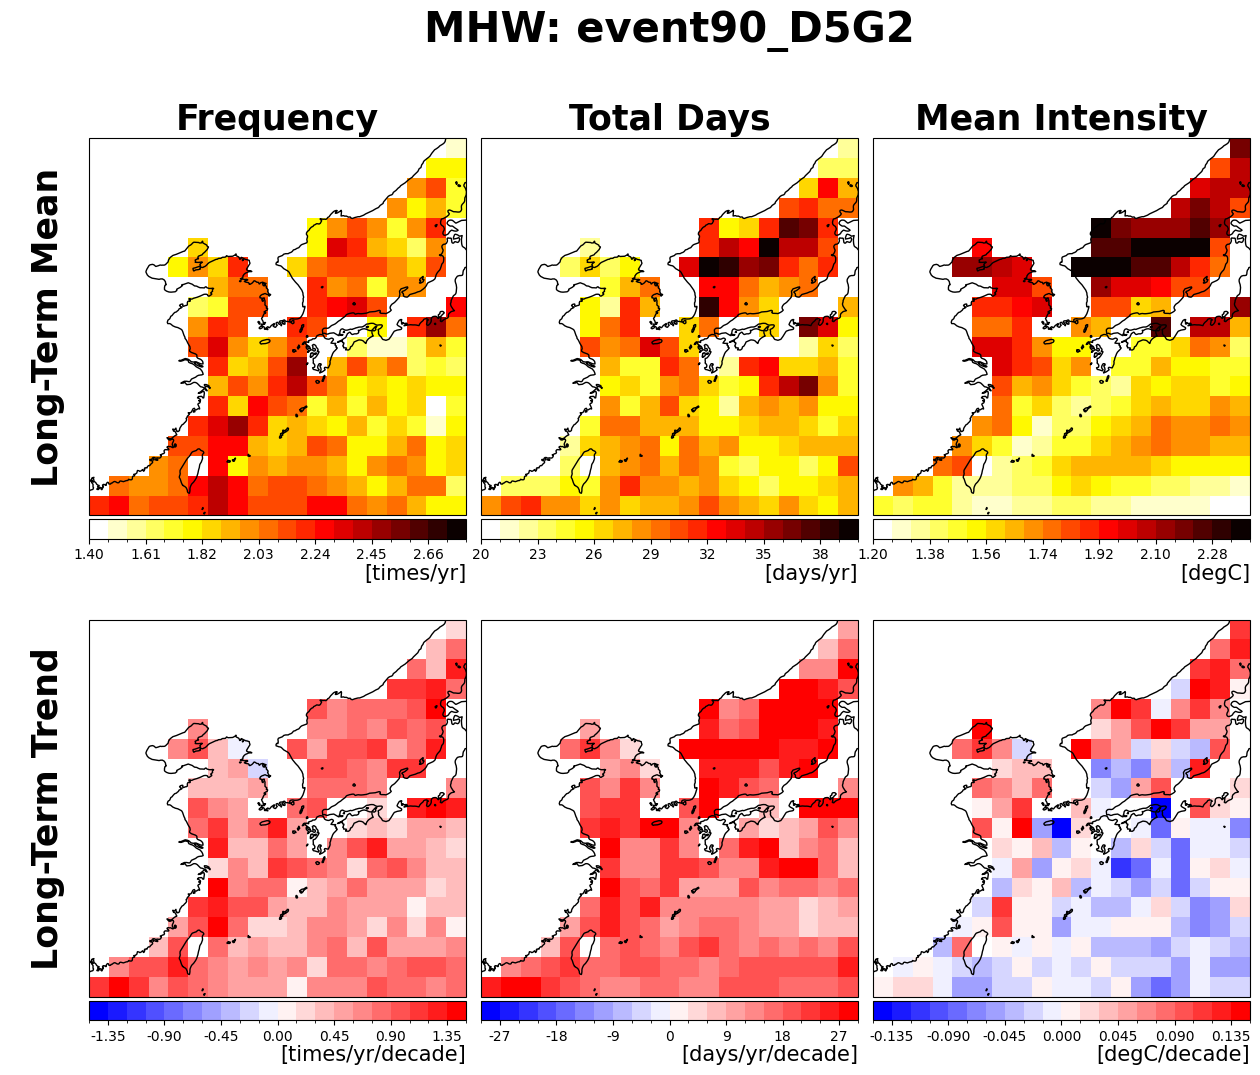

In [17]:
plt.close('all')
fig = plt.figure(figsize=(16, 13))
gs = gridspec.GridSpec(6, 4, wspace=0.05, hspace=0.0,
                        height_ratios=[0.3, 1, 0.05, 0.2, 1, 0.05],
                        width_ratios=[0.17, 1, 1, 1])
plt.rcParams['axes.unicode_minus'] = False

fs, fw, cb = 20, 'regular', 2

fig.add_subplot(gs[0, 2])
plt.text(0.5, 0.8, f'{hd.upper()}: {mtr}', fontsize=fs + 10, fontweight='heavy', ha='center')
plt.axis('off')
fig.add_subplot(gs[1, 0])
plt.text(0.6, 0.5, 'Long-Term Mean', fontsize=fs + 5, rotation=90, fontweight='heavy', ha='center', va='center')
plt.axis('off')
fig.add_subplot(gs[4, 0])
plt.text(0.6, 0.5, 'Long-Term Trend', fontsize=fs + 5, rotation=90, fontweight='heavy', ha='center', va='center')
plt.axis('off')

if hd == 'hr':
    unit = 'mm/day'
    mint = mint * 1000
    mint_t = mint_t * 1000
else:
    unit = 'degC'

ihd, cmap1, cmap2 = {'aht': (0, 'afmhot_r', 'RdBu_r'),
                      'hr': (1, 'YlGnBu', 'BrBG'),
                      'mhw': (2, 'hot_r', 'bwr')}[hd]

plot_configs = [
    {'row': 1, 'col': 1, 'data': frq, 'title': 'Frequency', 'unit': 'times/yr',
     'cmap': cmap1, 'ranges': {0: (4.8, 2.4), 1: (28., 14.), 2: (2.8, 1.4)}, 'nlevs': 21},
    {'row': 1, 'col': 2, 'data': dur, 'title': 'Total Days', 'unit': 'days/yr',
     'cmap': cmap1, 'ranges': {0: (30, 10), 1: (55., 45.), 2: (40., 20.)}, 'nlevs': 21},
    {'row': 1, 'col': 3, 'data': mint, 'title': 'Mean Intensity', 'unit': unit,
     'cmap': cmap1, 'ranges': {0: (8, 0), 1: (35, 5.), 2: (2.4, 1.2)}, 'nlevs': 21},
    {'row': 4, 'col': 1, 'data': frq_t, 'title': '', 'unit': 'times/yr/decade',
     'cmap': cmap2, 'ranges': {0: (2, -2.), 1: (1., -1), 2: (1.5, -1.5)}, 'nlevs': 21},
    {'row': 4, 'col': 2, 'data': dur_t, 'title': '', 'unit': 'days/yr/decade',
     'cmap': cmap2, 'ranges': {0: (2, -2.), 1: (1., -1), 2: (30, -30)}, 'nlevs': 21},
    {'row': 4, 'col': 3, 'data': mint_t, 'title': '', 'unit': f'{unit}/decade',
     'cmap': cmap2, 'ranges': {0: (.4, -.4), 1: (1, -1), 2: (.15, -.15)}, 'nlevs': 21},
]

for cfg in plot_configs:
    mx, mn = cfg['ranges'][ihd]
    levs = np.linspace(mn, mx, cfg['nlevs'])
    panel(cfg['row'], cfg['col'], lat, lon, cfg['data'], cfg['cmap'], levs, mn, mx,
          cfg['title'], fs, fw, 'center', cb, cfg['unit'], fig, gs)

fig.tight_layout(pad=0.0)
plt.show()


## 8. Save and display figure

Saved: /home/yyalee/ART_2026/Data4Inventory/forEastAsiaClimateExtremes/MHW.stats.maps__OISST.p90_D5G2.1982-2024.EA1.5.png


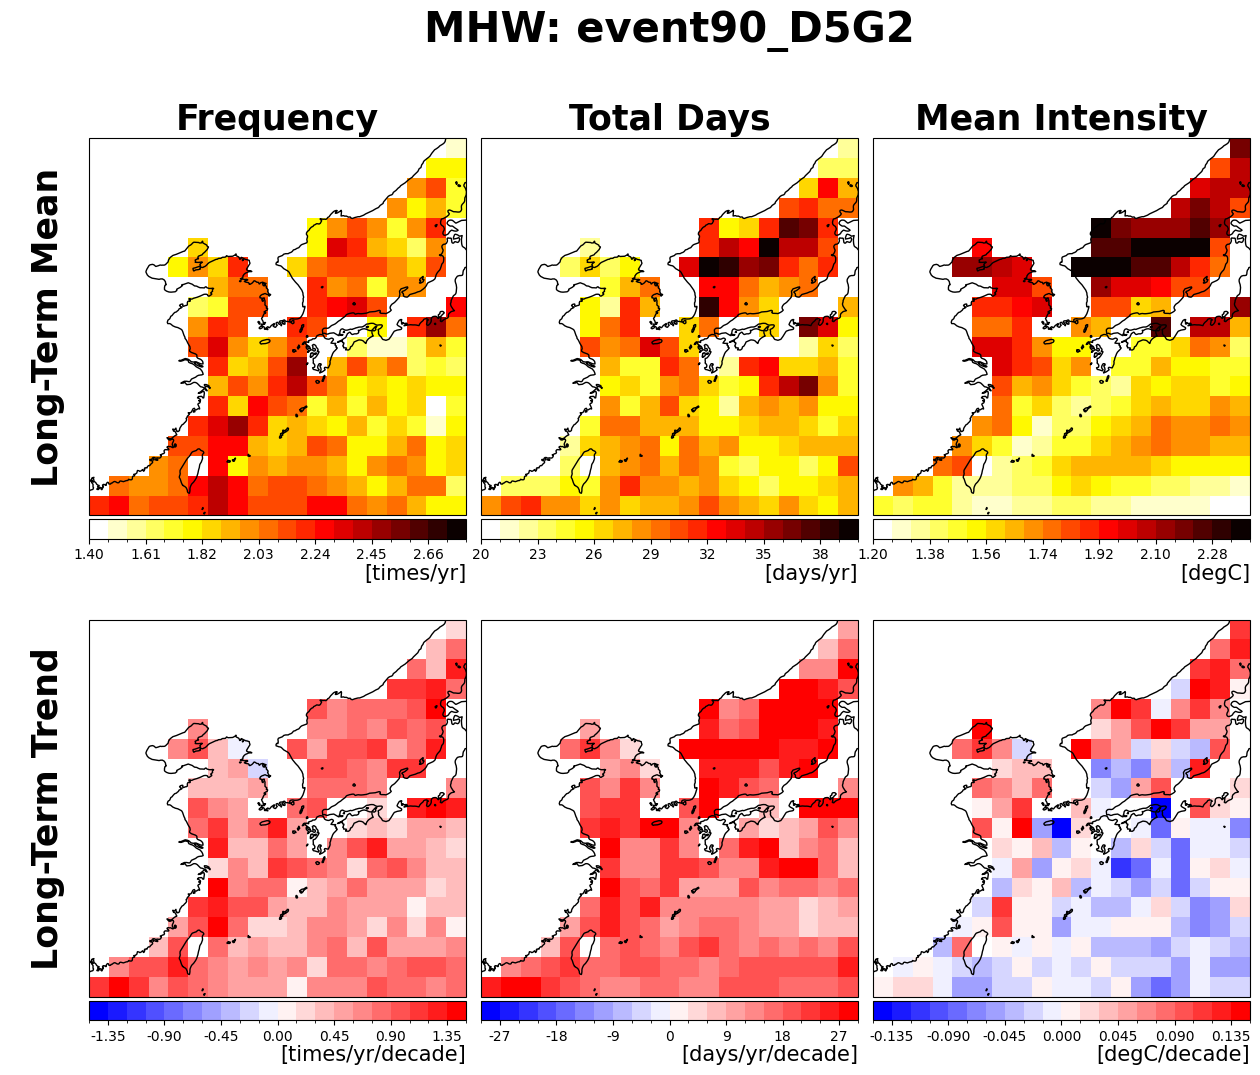

In [ ]:
os.makedirs(dir_out2, exist_ok=True)
ofn2 = dir_out2 + f"{hd.upper()}.stats.maps__{rean.upper()}.p{mtr[5:]}.{prd}.{rg}.png"
fig.savefig(ofn2, bbox_inches='tight')
print(f"Saved: {ofn2}")

#display(Image(filename=ofn2))
